In [1]:
import sys
import os

project_root = os.path.abspath("../../")
if project_root not in sys.path:
    sys.path.append(project_root)


In [2]:
from data_mining import Dataset
from experiments.domain_similarity.similarity_utils import (
    euclidean_centroid_distance,
    rbf_mmd,
    similarity_calculator,
    plot_triangular_similarity_heatmaps,
)

In [3]:
operations = {
    "step_drilling_250_100": {"operations": ["00", "01", "04", "14"],},
    "step_drilling_250_50": {"operations": ["06", "08", "10", "11", "12"],},
    "step_drilling_200_50": {"operations": ["05", "07"]},
    "step_drilling_250_330": {"operations": ["03"]},
    "drilling_200_50": {"operations": ["02"]},
    "straight_flute_250_50": {"operations": ["09"]},
    "tsc_75_25": {"operations": ["13"]},
}

for domain in operations.keys():
    operations[domain]["dataset"] = Dataset(
        operations=operations[domain]["operations"],
    )

    operations[domain]["dataset"].mine(win_len = 1000, hop_len = 1000);


/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_000.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_001.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_003.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_004.h5  ---  (264192, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_005.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_006.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_007.h5  ---  (269312, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP00/good/M01_Aug_2019_OP00_008.h5  ---  (268288, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_M

In [4]:
metrics_to_test = [
    {"name": "Euclidean (Centroids)", "func": euclidean_centroid_distance},
    {"name": "MMD (Distribution Space)", "func": rbf_mmd},
]
states = ["ALL", "good", "bad"]
normalizations = [False, True]

similarity_cases = []

for metric in metrics_to_test:
    for state in states:
        for normalization in normalizations:
            similarity_cases.append(
                {
                    "metric_name": metric["name"],
                    "arguments": {
                        "operations": operations,
                        "state": state,
                        "axix": ["0", "1", "2"],
                        "normalization": normalization,
                        "metric": metric["func"],
                    },
                    "diction": None,
                }
            )


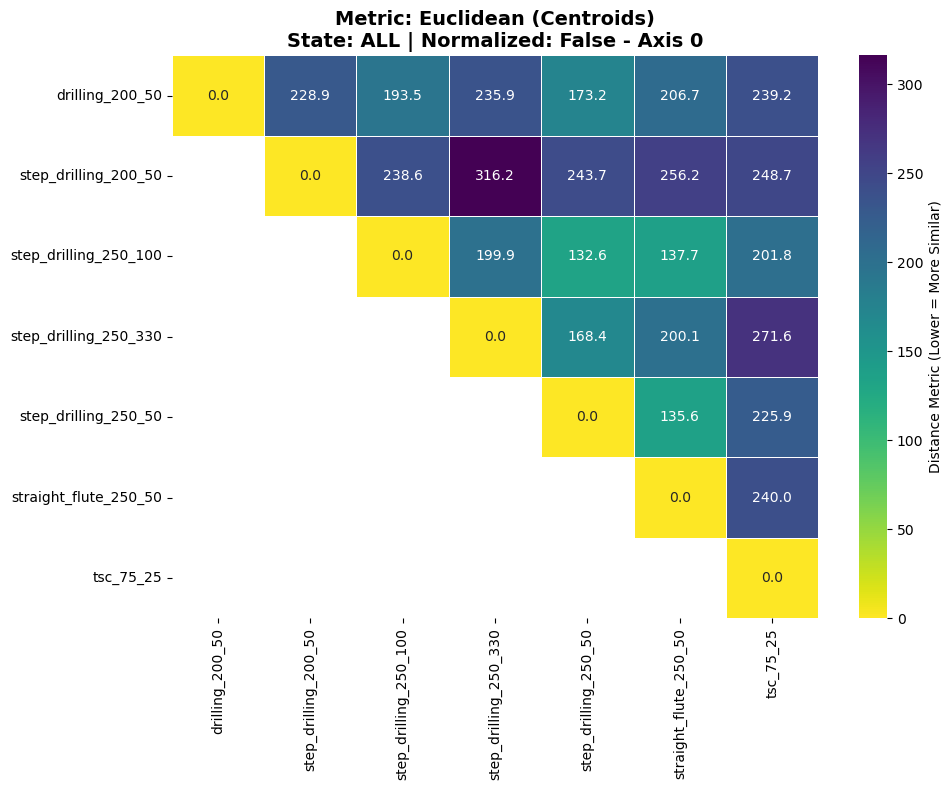

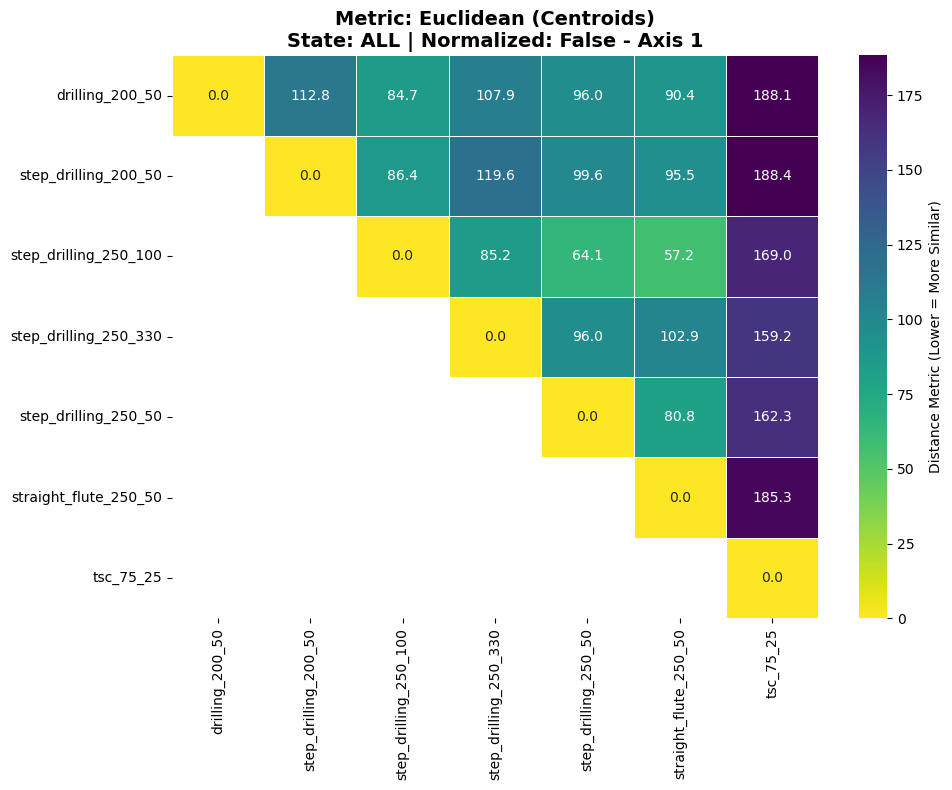

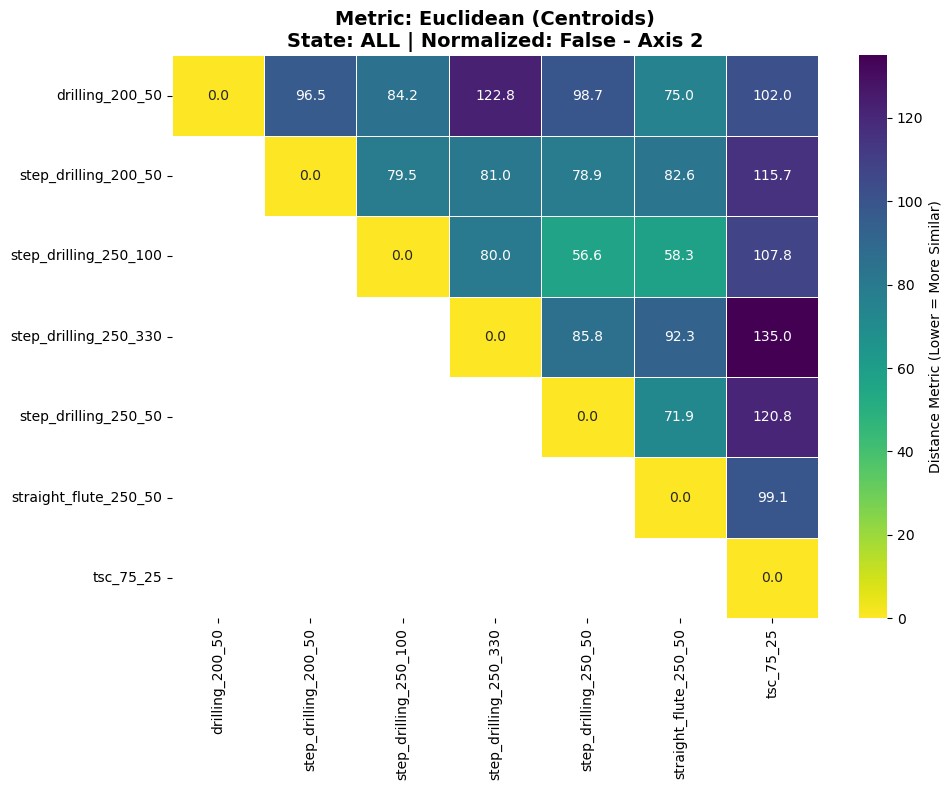

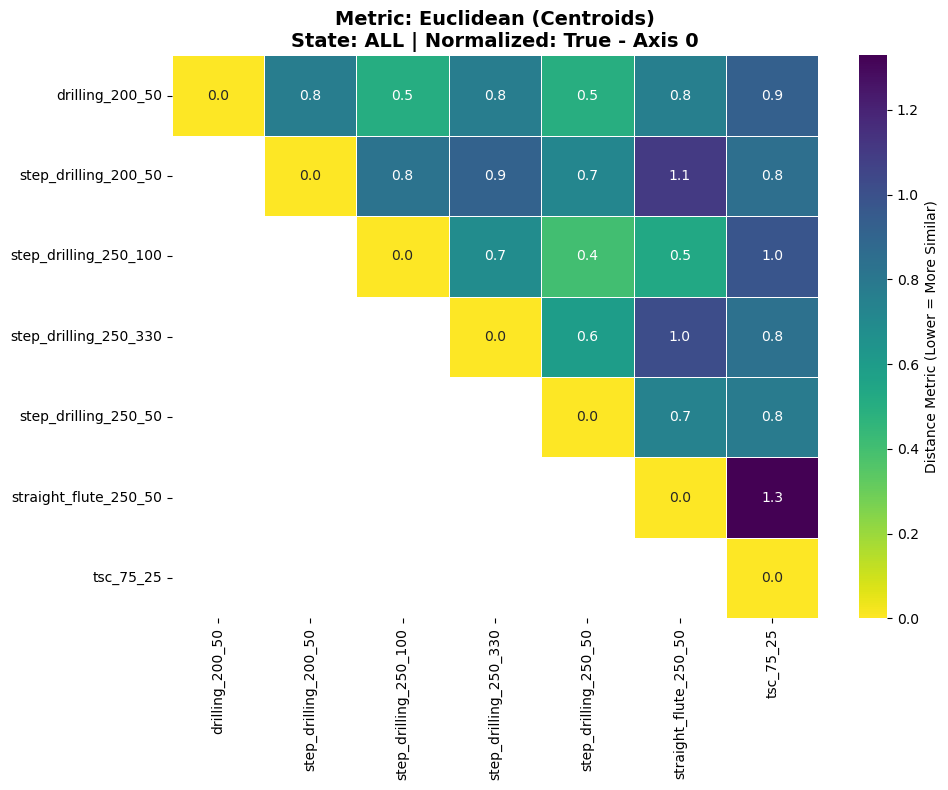

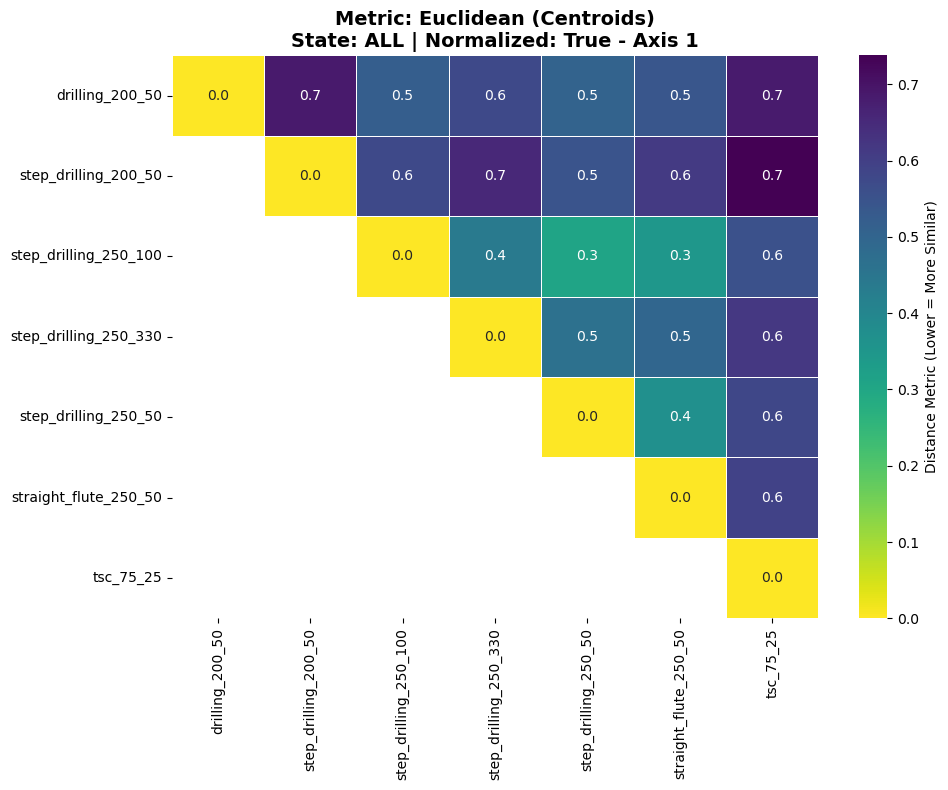

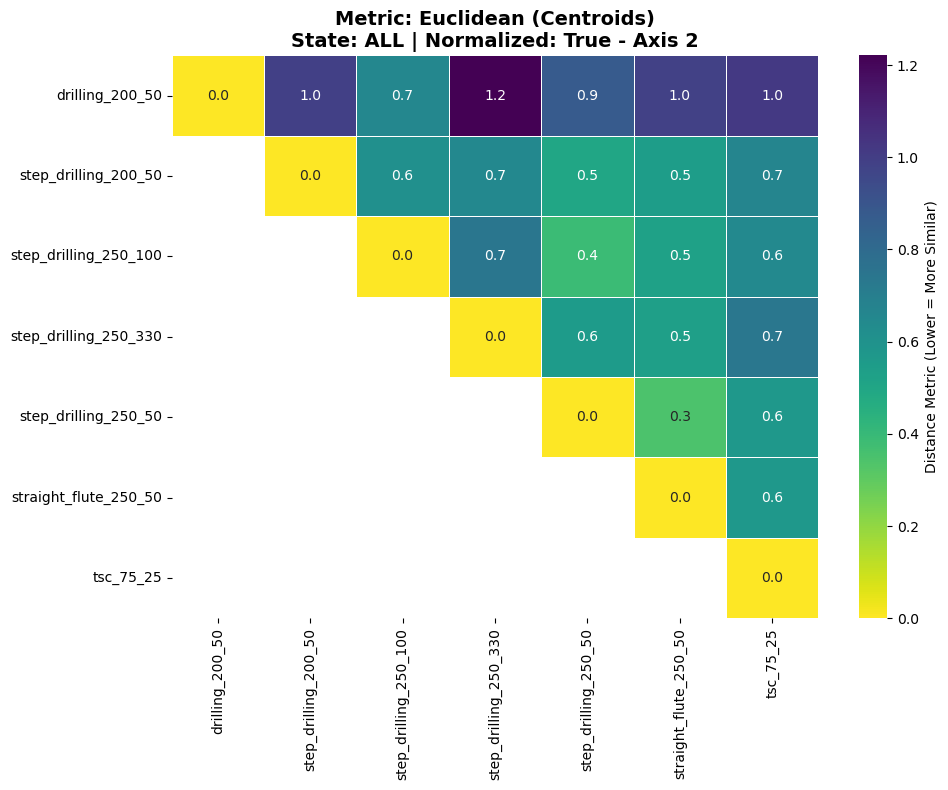

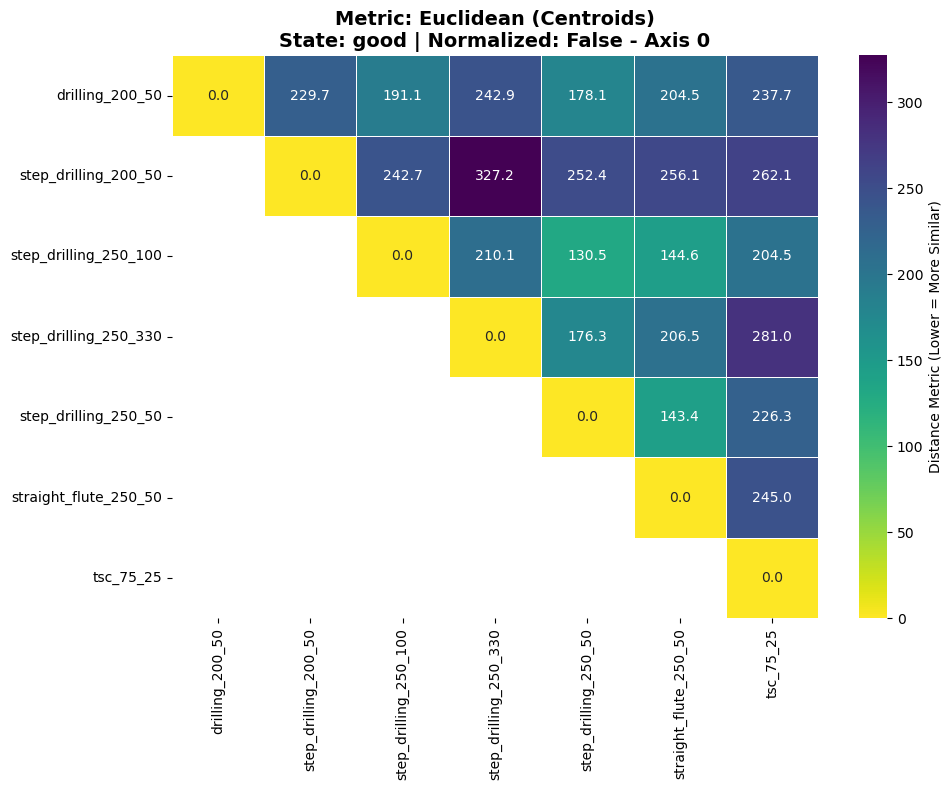

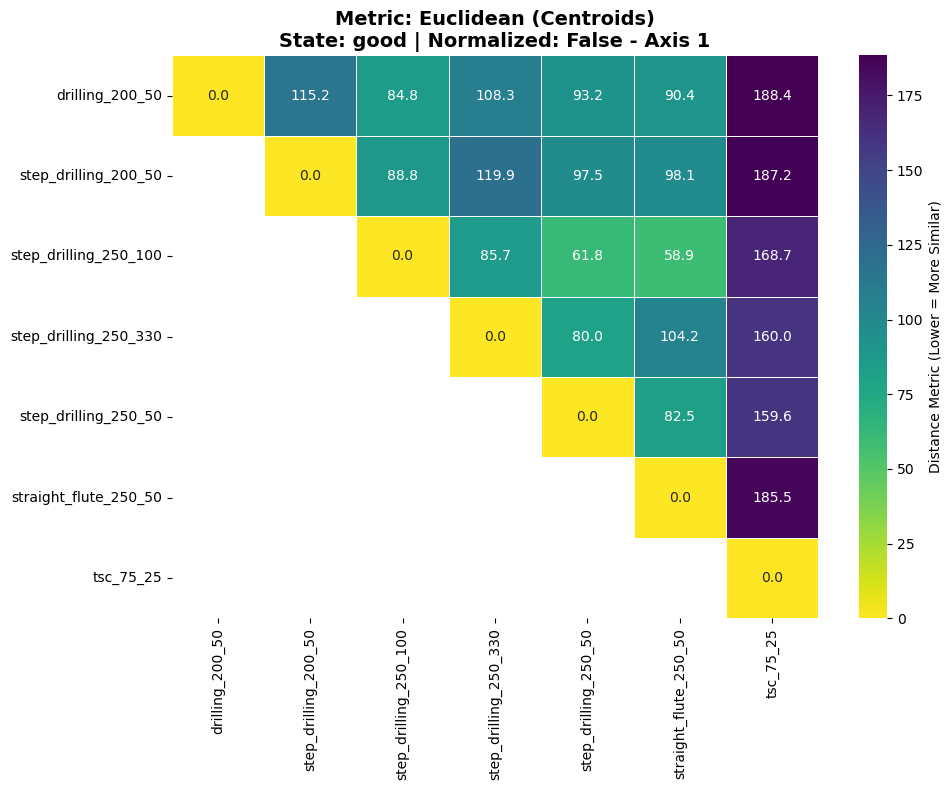

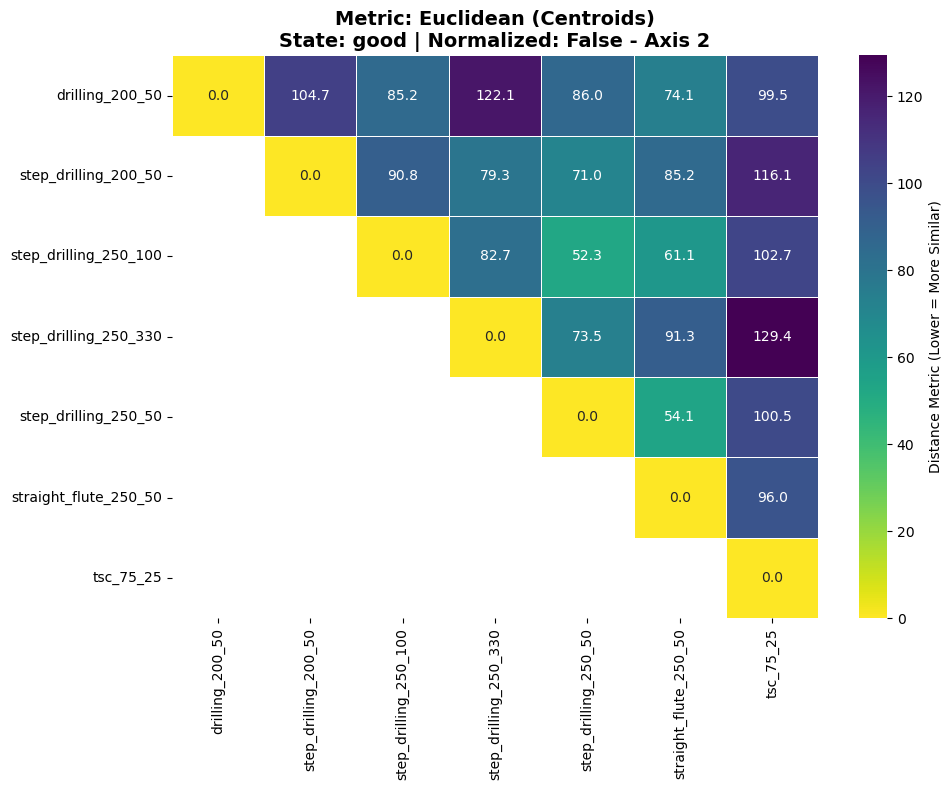

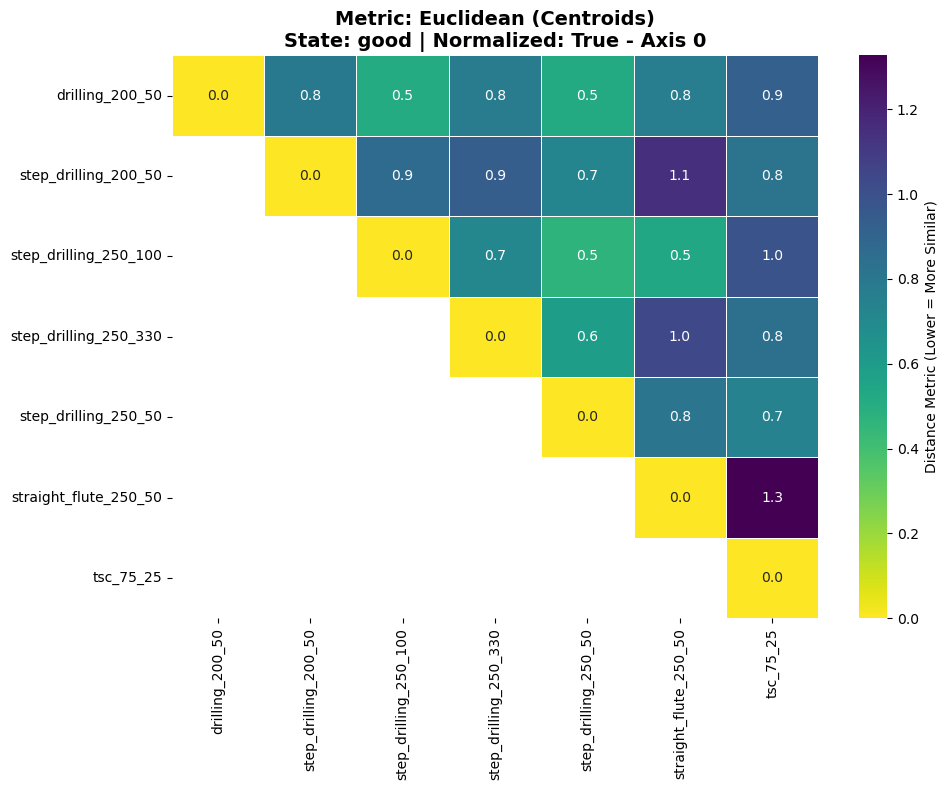

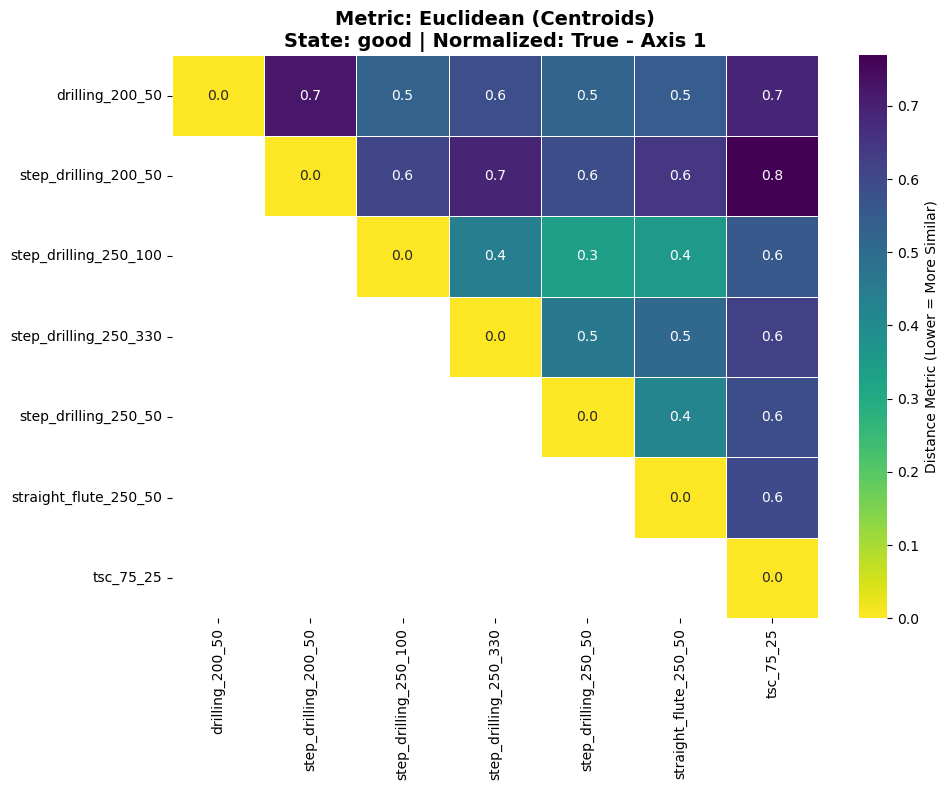

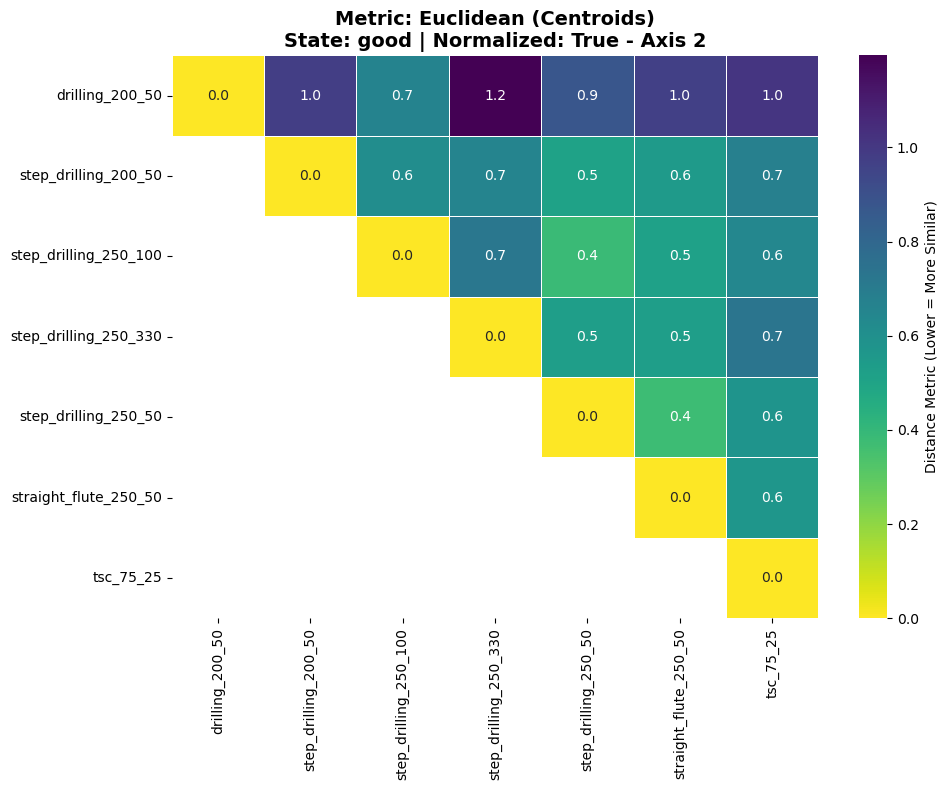

/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value

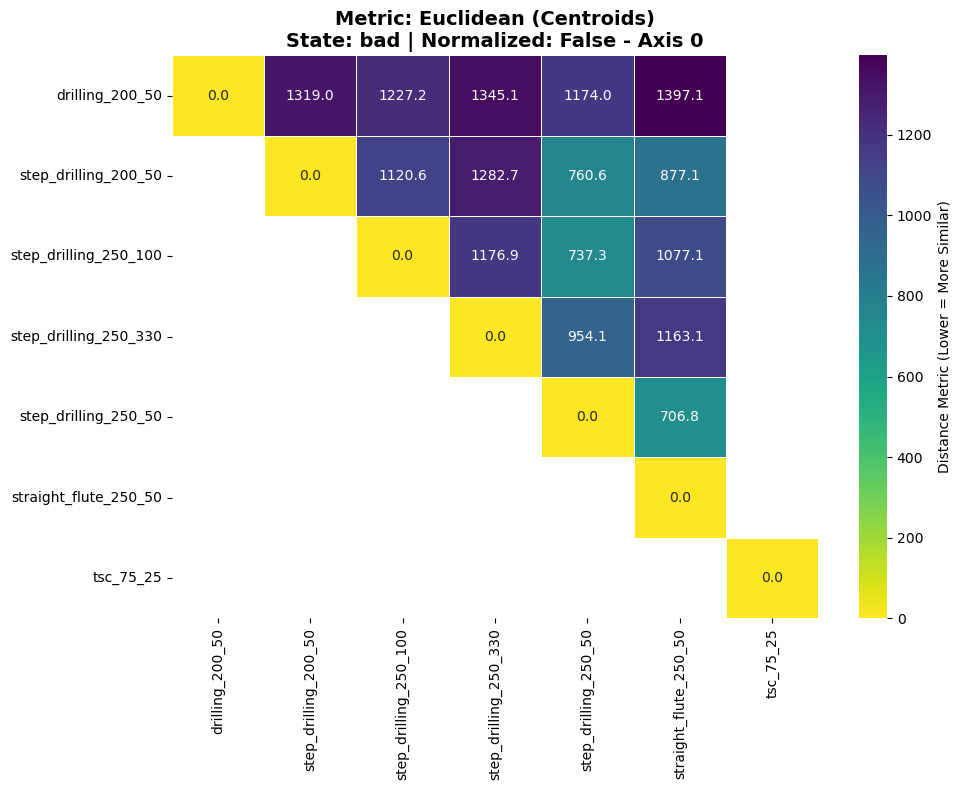

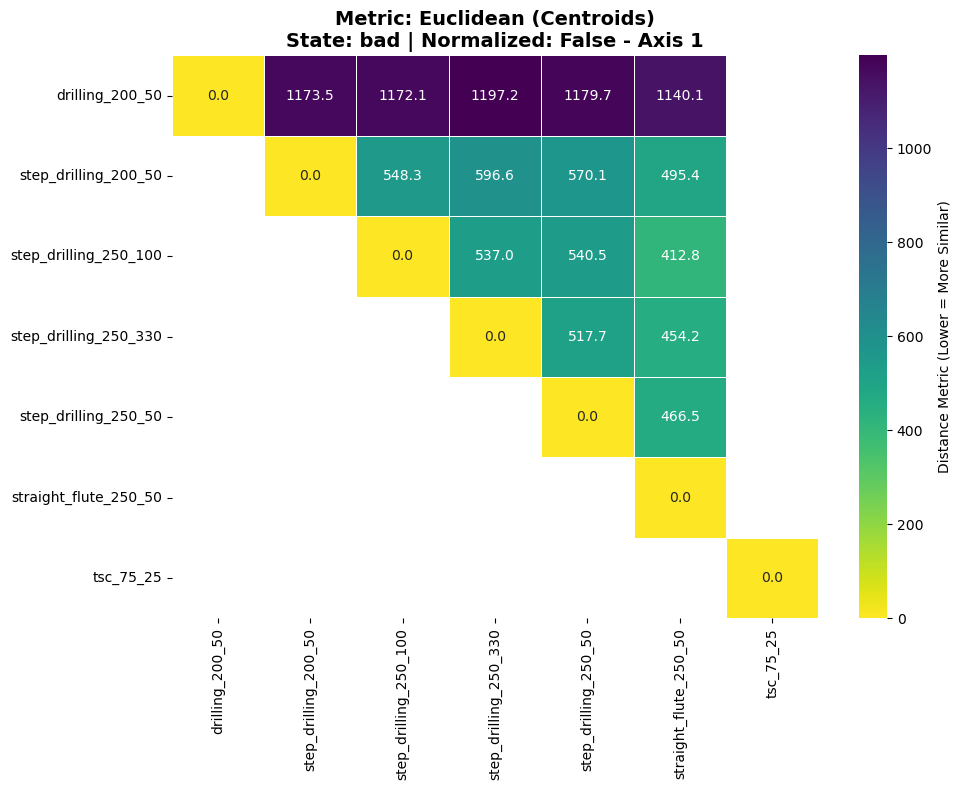

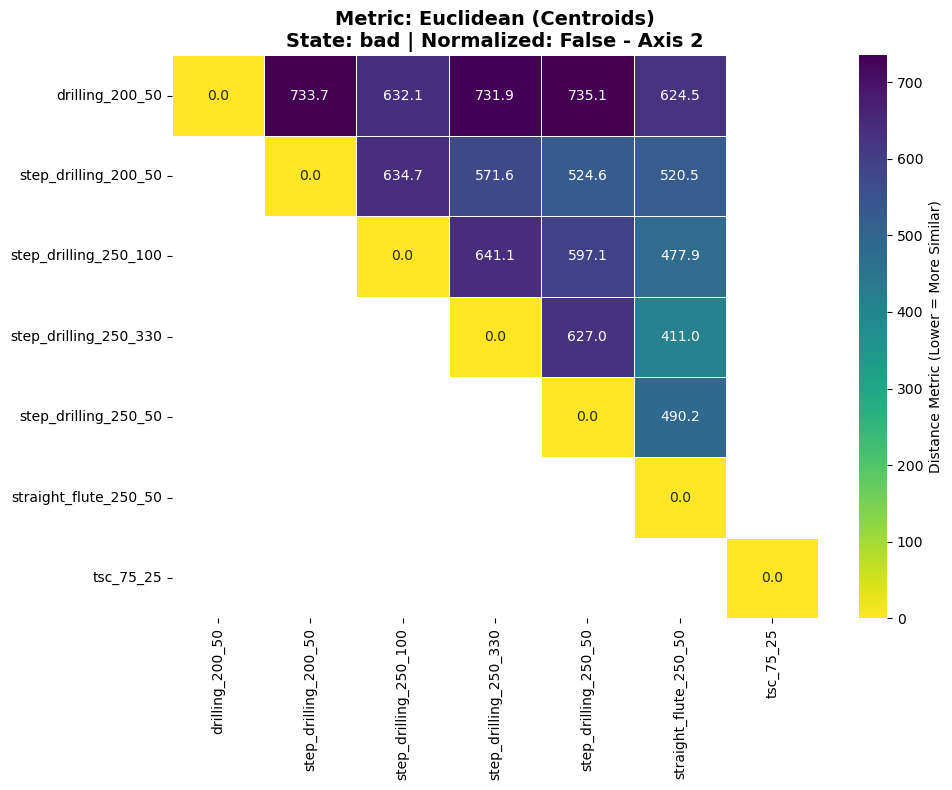

/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home2/a/amiber/projects/ml_for_pdm_project/experiments/domain_similarity/similarity_utils.py:19: RuntimeWarning: Mean of empty slice
  y_centroid = Y.mean(axis=0)
/nfs/home/amiber/conda_envs/ml_for_pdm_project_env/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value

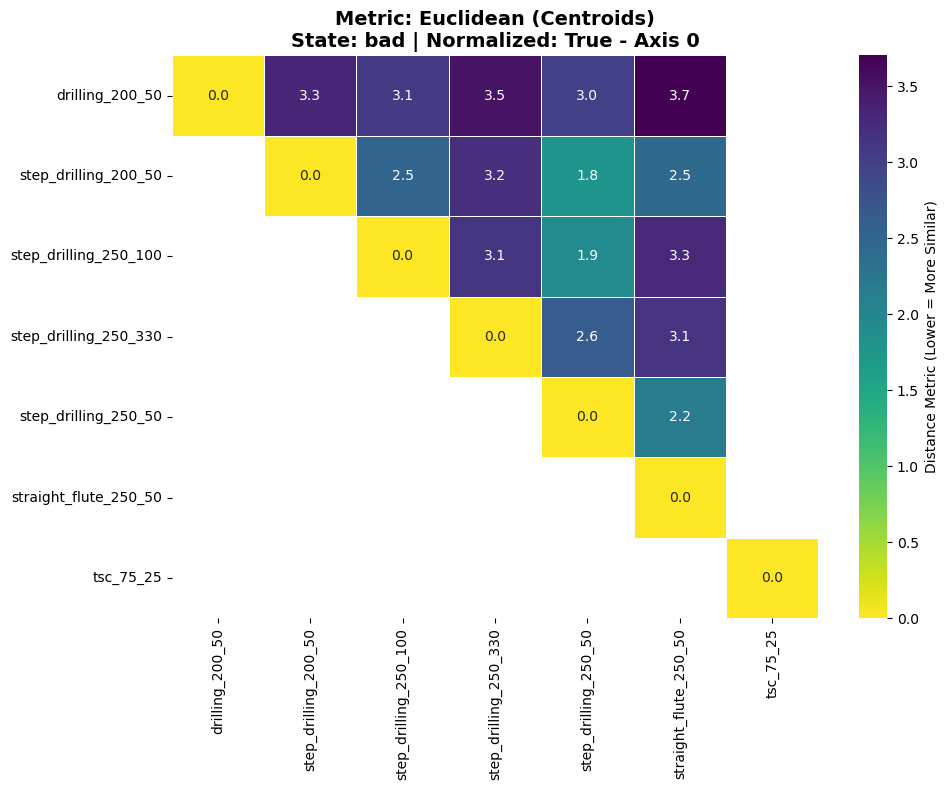

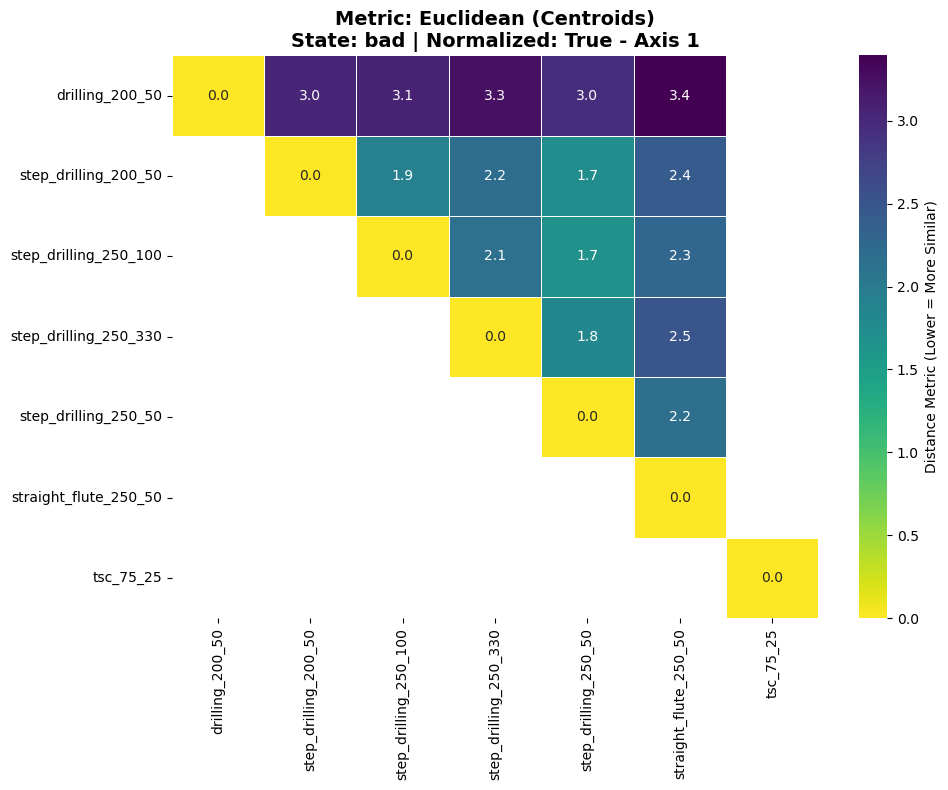

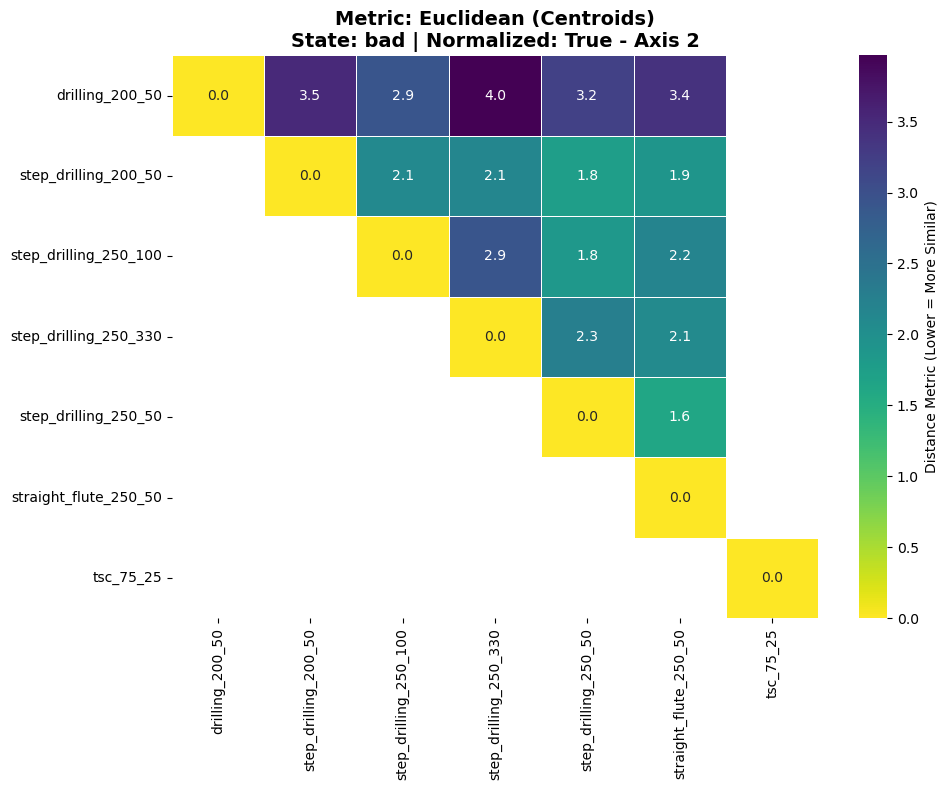

KeyboardInterrupt: 

In [5]:
for case in similarity_cases:
    # Runs the 50% faster upper-triangle algorithm
    case["diction"] = similarity_calculator(**case["arguments"])

    title = (
        f"Metric: {case['metric_name']}\n"
        f"State: {case['arguments']['state']} | "
        f"Normalized: {case['arguments']['normalization']}"
    )

    # Renders clean triangular heatmaps
    plot_triangular_similarity_heatmaps(case["diction"], base_title=title)
